## Exploring your own dataset

Having identified a dataset of interest to you, use this notebook to carry out whatever analyses you care to.  Remove the content from this Markdown cell, and populate the notebook with commentary, code, analyses, results, and figures as you see fit.

# My Data

I decided to analyze 311 data for the city I currently live in: Austin, TX. 311 is a non-emergency number you can dial to access government services. It can offer insights into where a city needs improvement as a separate metric from crime data. This dataset contains reported incidents ranging from fireworks complaints to broken stop lights.

I found the dataset in Austin's open data portal here in CSV format: https://data.austintexas.gov/Utilities-and-City-Services/Austin-311-Public-Data/xwdj-i9he/about_data

Because the dataset aggregates many years of data, it is very large and for the scope of this exercise I wanted to be more granular. Therefore I used the website's query tool to download only 311 data from this year, 2025.


I am interested in what the most common 311 complaints are and where they are concentrated in the city.

In [9]:

import pandas as pd


In [11]:
# Loading the data into a dataframe
df = pd.read_csv(r"C:\Users\martinee2\Downloads\Austin_311_Public_Data_20250909.csv")
df

,Service Request (SR) Number,SR Description,Owning Department,Method Received,SR Status,Status Change Date,Created Date,Last Update Date,Close Date,SR Location,...,Zip Code,County,State Plane X Coordinate,State Plane Y Coordinate,Latitude Coordinate,Longitude Coordinate,(Latitude.Longitude),Council District,Map Page,Map Tile
0,25-00000782,APD - Non Emergency Noise/Alarm,Austin Police Department,Spot311 Interface,Closed,01/01/2025 07:12:49 PM,01/01/2025 07:07:50 PM,01/01/2025 07:12:49 PM,01/01/2025 07:12:49 PM,"9410 TEASDALE TER, AUSTIN, TX 78753",...,78753.0,TRAVIS,3.133046e+06,1.010290e+07,30.355212,-97.681057,POINT (-97.68105709 30.35521194),4.0,526L,MM29
1,25-00000783,TPW - Traffic Sign Maintenance,Transportation and Public Works,Citizen Web Intake,Closed,01/02/2025 06:58:00 AM,01/01/2025 07:09:52 PM,01/02/2025 07:03:31 AM,01/02/2025 06:58:00 AM,"9718 CURLEW DR, AUSTIN, TX 78748",...,78748.0,TRAVIS,3.086320e+06,1.003766e+07,30.178854,-97.833812,POINT (-97.83381199 30.17885429),5.0,672M,MD14
2,25-00000784,ZZ - AFD - Fireworks Complaint,Austin Fire Department,Phone,Closed,01/04/2025 01:24:06 PM,01/01/2025 07:10:41 PM,01/04/2025 01:24:06 PM,01/04/2025 01:24:06 PM,"5601 EMMA THOMPSON WAY, AUSTIN, TX 78747",...,78747.0,TRAVIS,3.107099e+06,1.002474e+07,30.142050,-97.769012,POINT (-97.76901184 30.1420499),2.0,704L,MH11
3,25-00000786,ARR - Dead Animal Collection,Austin Resource Recovery,Phone,Closed,01/02/2025 08:20:28 AM,01/01/2025 07:12:09 PM,01/02/2025 08:20:28 AM,01/02/2025 08:20:28 AM,"907 E ST JOHNS AVE, AUSTIN, TX 78752",...,78752.0,TRAVIS,3.126837e+06,1.009402e+07,30.331223,-97.701403,POINT (-97.701403 30.33122348),4.0,556A,ML27
4,25-00000788,311 CC - Other,311-Command Center,Spot311 Interface,Closed,01/02/2025 08:26:51 AM,01/01/2025 07:13:54 PM,01/02/2025 08:26:51 AM,01/02/2025 08:26:51 AM,"7033 UNION PARK LN, AUSTIN, TX 78744",...,78744.0,TRAVIS,3.121734e+06,1.003054e+07,30.157050,-97.722295,POINT (-97.72229528 30.15704974),2.0,675Y,MK13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214308,25-00305403,APD - Non Emergency Noise/Alarm,Austin Police Department,Phone,Closed,09/08/2025 11:36:49 PM,09/08/2025 11:33:36 PM,09/08/2025 11:36:49 PM,09/08/2025 11:36:49 PM,"9725 NORTH LAKE CREEK PKWY, AUSTIN, TX 78717",...,78717.0,WILLIAMSON,3.096524e+06,1.014651e+07,30.477426,-97.793665,POINT (-97.79366489 30.47742598),6.0,403Z,MF40
214309,25-00305404,DSD - Request Code Officer,Development Services Department,Phone,Open,09/08/2025 11:38:06 PM,09/08/2025 11:38:06 PM,09/08/2025 11:47:01 PM,NaN,"13301 CENTER LAKE DR, AUSTIN, TX 78753",...,78753.0,TRAVIS,3.137525e+06,1.012259e+07,30.409045,-97.665362,POINT (-97.66536209 30.40904524),7.0,467S,MN34
214310,25-00305405,Pet Resource Center - Found Pet Report,Animal Services Office,Spot311 Interface,Open,09/08/2025 11:49:03 PM,09/08/2025 11:49:03 PM,09/08/2025 11:49:03 PM,NaN,"12924 HEYERDAHL DR, AUSTIN, TX 78753",...,78753.0,TRAVIS,3.141953e+06,1.012008e+07,30.401863,-97.651511,POINT (-97.65151059 30.40186345),7.0,497B,MN33
214311,25-00305406,AE Street Light Issue - Address,Austin Energy Department,Spot311 Interface,New,09/08/2025 11:51:04 PM,09/08/2025 11:51:04 PM,09/08/2025 11:51:04 PM,NaN,"2525 BITTER CREEK DR, AUSTIN, TX 78744",...,78744.0,TRAVIS,3.111410e+06,1.003933e+07,30.181884,-97.754308,POINT (-97.75430806 30.18188427),2.0,674H,MH15


In [12]:
# Count the number of unique departments assigned to 311 complaints
departments = df['Owning Department'].nunique()
department_names = df['Owning Department'].unique()
print(f"There are {departments} unique departments that handle 311 complaints.\nThese departments are:\n")

for n in department_names:
    print(n)

There are 18 unique departments that handle 311 complaints.
These departments are:

Austin Police Department
Transportation and Public Works
Austin Fire Department
Austin Resource Recovery
311-Command Center
Animal Services Office
Parks & Recreation Department
Development Services Department
Public Health
311-Client and Information Servi
Watershed Protection
Austin Water
Austin Energy Department
Corporate Public Information Off
(Tara) Financial Services Depart
Telecommunications & Regulatory
Housing
Homeland Security and Emergency


# Busiest Departments in 2025

Now that we know the departments, I'd like to know which department handles the most complaints and which handles the least in 2025. We can achieve this using the pandas value_counts method, which counts the frequency of unique values in a column, and lists them in descending order.

In [19]:
pd.set_option('display.max_rows', None)
df3 = pd.DataFrame(df['SR Description'].value_counts())
df3

,count
SR Description,
ARR - Garbage,17481
APD - Non Emergency Noise/Alarm,17367
DSD - Request Code Officer,16595
TPW - Parking Violation Enforcement,12782
ARR - Compost,9880
ARR - Bulk,8953
ARR - Recycling,8539
TPW - Traffic Signal - Maintenance,8155
APD - Vehicle Abatement Report,6243


# Results

We can see that the department that handled the most complaints in 2025 is Austin Resource Recovery with a total of 61,867 complaints. The department that handled the least was Telecommunications & Regulatory with only 1 complaint. Now I'd like to filter the data to just one department.

In [13]:
df2 = df[df['Owning Department'] == 'Austin Resource Recovery']
df2

,Service Request (SR) Number,SR Description,Owning Department,Method Received,SR Status,Status Change Date,Created Date,Last Update Date,Close Date,SR Location,...,Zip Code,County,State Plane X Coordinate,State Plane Y Coordinate,Latitude Coordinate,Longitude Coordinate,(Latitude.Longitude),Council District,Map Page,Map Tile
3,25-00000786,ARR - Dead Animal Collection,Austin Resource Recovery,Phone,Closed,01/02/2025 08:20:28 AM,01/01/2025 07:12:09 PM,01/02/2025 08:20:28 AM,01/02/2025 08:20:28 AM,"907 E ST JOHNS AVE, AUSTIN, TX 78752",...,78752.0,TRAVIS,3.126837e+06,1.009402e+07,30.331223,-97.701403,POINT (-97.701403 30.33122348),4.0,556A,ML27
6,25-00000790,ARR - Dead Animal Collection,Austin Resource Recovery,Phone,Duplicate (closed),01/02/2025 08:20:28 AM,01/01/2025 07:14:30 PM,01/02/2025 08:20:27 AM,01/02/2025 08:20:28 AM,"907 E ST JOHNS AVE, AUSTIN, TX 78752",...,78752.0,TRAVIS,3.126837e+06,1.009402e+07,30.331223,-97.701403,POINT (-97.701403 30.33122348),4.0,556A,ML27
14,25-00000799,ARR - Recycling,Austin Resource Recovery,Phone,Closed,01/06/2025 11:35:09 AM,01/01/2025 07:27:09 PM,01/06/2025 11:35:09 AM,01/06/2025 11:35:09 AM,"2612 BAXTER DR, AUSTIN, TX 78745",...,78745.0,TRAVIS,3.093241e+06,1.005077e+07,30.214457,-97.810973,POINT (-97.81097341 30.2144573),5.0,643L,MF17
30,25-00000824,ARR - Recycling,Austin Resource Recovery,Phone,Closed,01/02/2025 01:42:40 PM,01/01/2025 08:02:03 PM,01/02/2025 01:42:40 PM,01/02/2025 01:42:40 PM,"7207 BILL HUGHES RD, AUSTIN, TX 78745",...,78745.0,TRAVIS,3.100587e+06,1.004206e+07,30.190066,-97.788352,POINT (-97.78835222 30.19006564),2.0,674A,MG15
43,25-00000842,ARR - Dead Animal Collection,Austin Resource Recovery,Spot311 Interface,Duplicate (closed),01/02/2025 10:41:05 AM,01/01/2025 08:28:27 PM,01/02/2025 10:41:04 AM,01/02/2025 10:41:05 AM,"6005 MESA DR, AUSTIN, TX 78731",...,78731.0,TRAVIS,3.104621e+06,1.009912e+07,30.346672,-97.771429,POINT (-97.77142911 30.34667155),10.0,524P,MG29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214281,25-00305365,ARR - Garbage,Austin Resource Recovery,Phone,Open,09/08/2025 09:20:44 PM,09/08/2025 09:20:44 PM,09/08/2025 09:20:44 PM,NaN,"2509 DOVEHILL DR, AUSTIN, TX 78744",...,78744.0,TRAVIS,3.111488e+06,1.004193e+07,30.189012,-97.753869,POINT (-97.75386916 30.18901228),2.0,674D,MH15
214287,25-00305373,ARR - Garbage,Austin Resource Recovery,Phone,Open,09/08/2025 09:38:10 PM,09/08/2025 09:38:10 PM,09/08/2025 09:38:10 PM,NaN,"7103 MEADOW RUN, AUSTIN, TX 78745",...,78745.0,TRAVIS,3.097187e+06,1.004440e+07,30.196711,-97.798944,POINT (-97.79894375 30.19671126),2.0,643Z,MF16
214293,25-00305381,ARR - General,Austin Resource Recovery,Phone,Open,09/08/2025 09:52:28 PM,09/08/2025 09:52:28 PM,09/08/2025 09:52:28 PM,NaN,"5213 BUFFALO PASS, AUSTIN, TX 78745",...,78745.0,TRAVIS,3.096519e+06,1.005345e+07,30.221636,-97.800405,POINT (-97.80040462 30.22163585),5.0,643D,MF18
214301,25-00305393,ARR - Garbage,Austin Resource Recovery,Phone,Open,09/08/2025 10:40:28 PM,09/08/2025 10:40:28 PM,09/08/2025 10:40:28 PM,NaN,"5812 GORHAM GLEN LN, AUSTIN, TX 78739",...,78739.0,TRAVIS,3.069081e+06,1.003963e+07,30.185323,-97.888217,POINT (-97.88821718 30.18532321),8.0,671G,MB15


With just the highest volume department, we can now see what the highest frequency complaint is.

In [14]:
df2['SR Description'].value_counts()

ARR - Garbage                         17481
ARR - Compost                          9880
ARR - Bulk                             8953
ARR - Recycling                        8539
ARR - Dead Animal Collection           4369
ARR - General                          4000
ARR - Brush                            3238
ARR - Storm Debris Collection          2449
ARR - Street Sweeping                   907
ARR - Household Hazardous Waste         758
ARR - Collection Truck Spillage         477
ZZ - ARR - Storm Debris Collection      364
ARR - Property Damage Report            262
ARR - Special Services                  155
ARR - Pet Search                         35
Name: SR Description, dtype: int64

# Results Part 2

From this analysis, we can see that the most common 311 request is garbage collection. Now we can explore where in the city this complaint most frequently occurs.

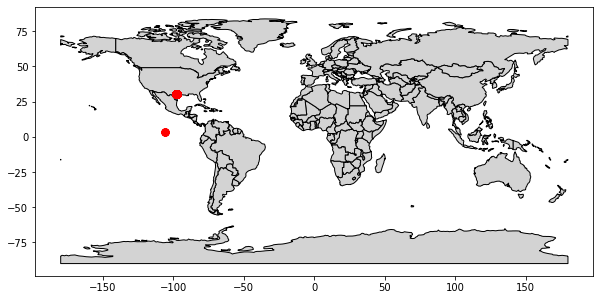

In [15]:
from shapely.geometry import Point
import matplotlib.pyplot as plt
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
gdf = gpd.GeoDataFrame(df2, geometry = gpd.points_from_xy(df2['Longitude Coordinate'], df2['Latitude Coordinate']), crs = "EPSG:4326")
fig, ax = plt.subplots(figsize=(10, 8))
world.plot(ax=ax, color='lightgray', edgecolor='black')
gdf.plot(ax=ax, marker='o', color='red', markersize=50)
plt.show()